In [ ]:
from google.colab import drive
import pandas as pd
import sys, os, glob, csv
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# CSV loader for Colab (local)
#'/content/drive/MyDrive/ColabNotebooks/datasets/pokemons.csv' Adi Path
#/content/drive/MyDrive/Advanced Machine Learning/Pandas /pokemons.csv (stella)

plt.rcParams['figure.figsize'] = (8,5)
plt.rcParams['axes.grid'] = True

CSV_PATH = '/content/drive/MyDrive/Advanced Machine Learning/Pandas /pokemons.csv'  # <-- change depending on user
from google.colab import drive, files
drive.mount('/content/drive', force_remount=True)
df = pd.read_csv(CSV_PATH)

print("Loaded:", df.shape, "from:", CSV_PATH)
df.head()

Mounted at /content/drive
Loaded: (1025, 18) from: /content/drive/MyDrive/Advanced Machine Learning/Pandas /pokemons.csv


,id,name,rank,generation,evolves_from,type1,type2,hp,atk,def,spatk,spdef,speed,total,height,weight,abilities,desc
0,1,bulbasaur,ordinary,generation-i,nothing,grass,poison,45,49,49,65,65,45,318,7,69,overgrow chlorophyll,A strange seed was planted on its back at birt...
1,2,ivysaur,ordinary,generation-i,bulbasaur,grass,poison,60,62,63,80,80,60,405,10,130,overgrow chlorophyll,"When the bulb on its back grows large, it appe..."
2,3,venusaur,ordinary,generation-i,ivysaur,grass,poison,80,82,83,100,100,80,525,20,1000,overgrow chlorophyll,The plant blooms when it is absorbing solar en...
3,4,charmander,ordinary,generation-i,nothing,fire,NaN,39,52,43,60,50,65,309,6,85,blaze solar-power,"Obviously prefers hot places. When it rains, s..."
4,5,charmeleon,ordinary,generation-i,charmander,fire,NaN,58,64,58,80,65,80,405,11,190,blaze solar-power,"When it swings its burning tail, it elevates t..."


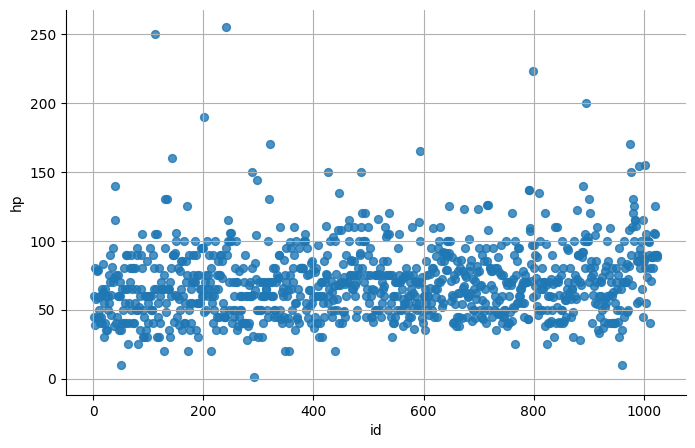

In [ ]:
# @title id vs hp
df.plot(kind='scatter', x='id', y='hp', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

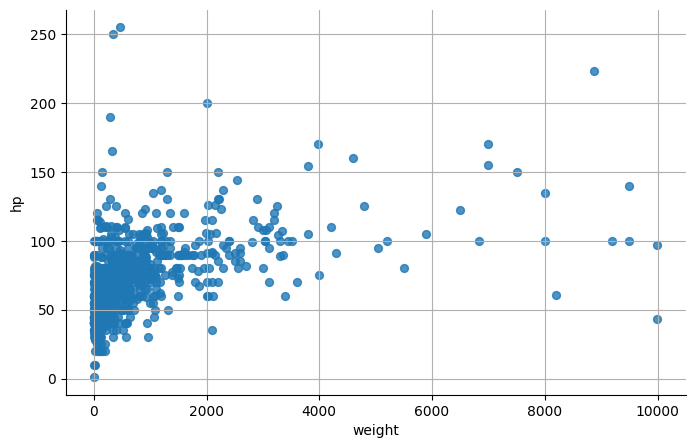

In [ ]:
df.plot(kind='scatter', x='weight', y='hp', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

/tmp/ipython-input-1083377974.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(df, x='atk', y='rank', inner='box', palette='Dark2')


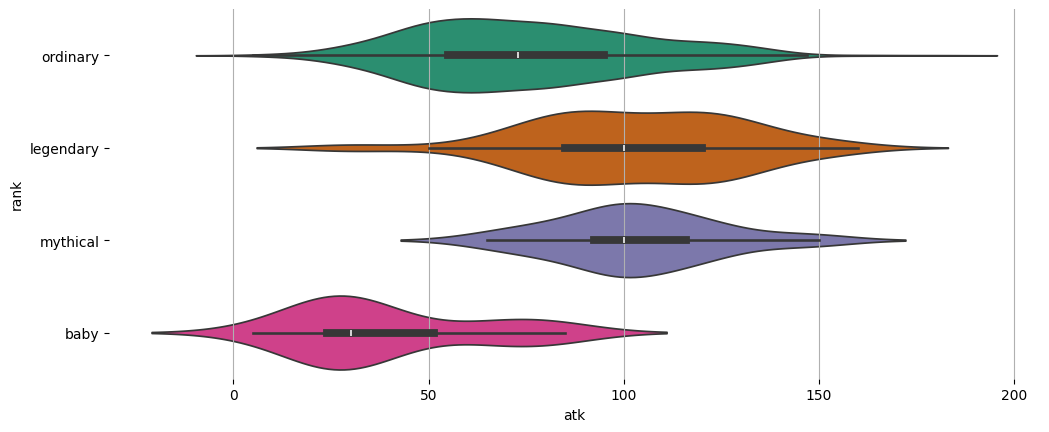

In [ ]:
# @title rank vs atk

from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(df['rank'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(df, x='atk', y='rank', inner='box', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

/tmp/ipython-input-380071997.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(df, x='atk', y='generation', inner='box', palette='Dark2')


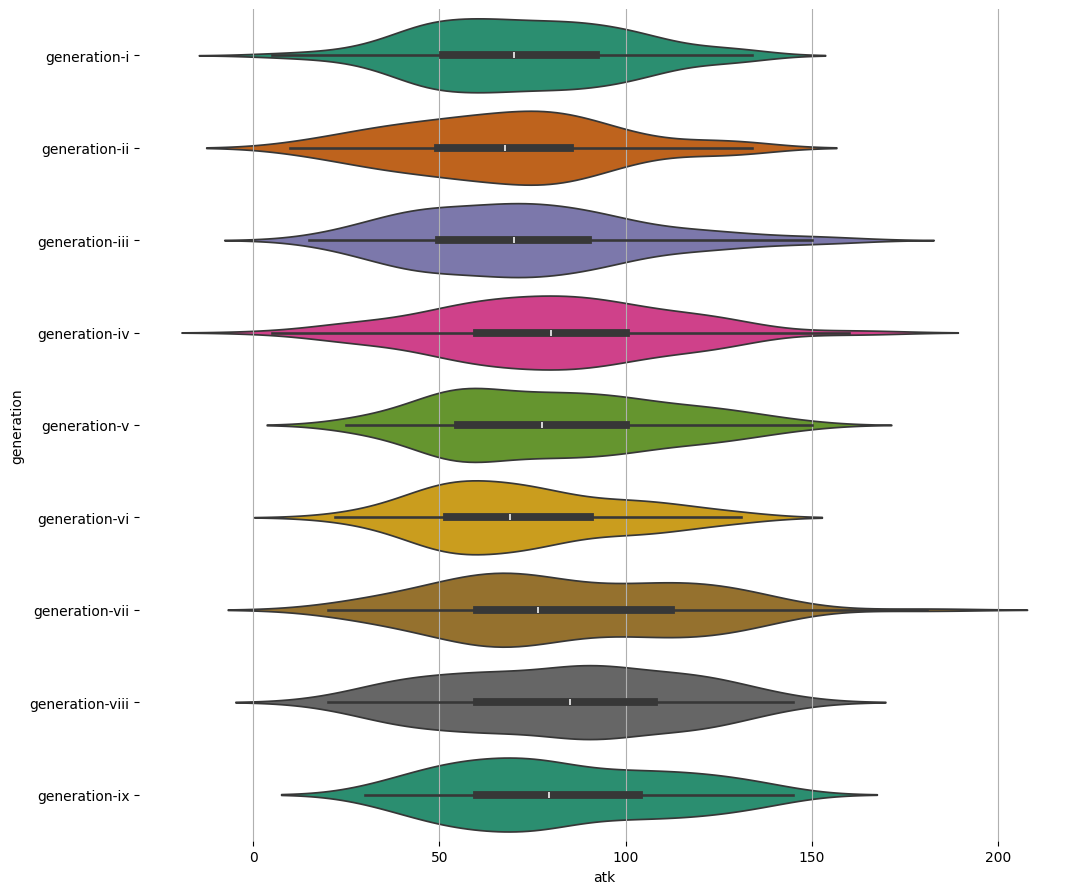

In [ ]:
#Generation vs attack

from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(df['generation'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(df, x='atk', y='generation', inner='box', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

In [ ]:
from __future__ import annotations
import re
import os

def numeralInt(s: str) -> int:
    """Why: dataset uses roman numerals (generation-iv)."""
    m = {"i": 1, "v": 5, "x": 10, "l": 50, "c": 100, "d": 500, "m": 1000}
    s = s.lower()
    total, prev = 0, 0
    for ch in reversed(s):
        val = m[ch]
        if val < prev:
            total -= val
        else:
            total += val
            prev = val
    return total


def genInt(g: str) -> float:
    m = re.search(r"generation-([ivxlcdm]+)", str(g).lower())
    if m:
        return float(numeralInt(m.group(1)))
    try:
        return float(g)
    except Exception:
        return float("nan")

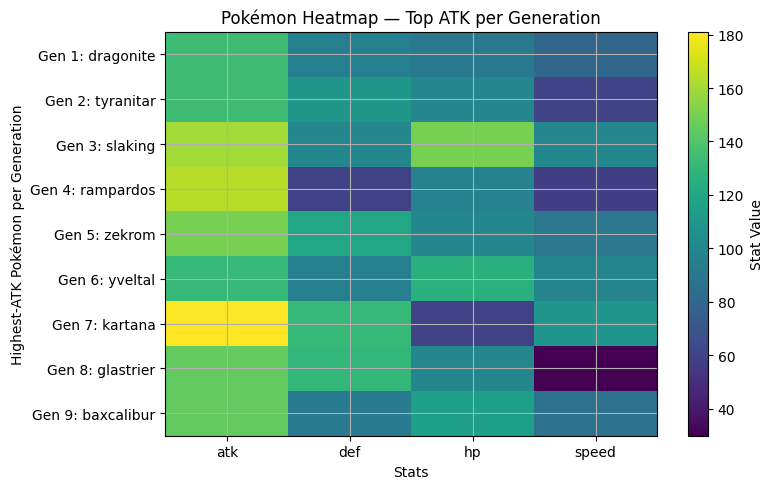

In [ ]:

required = {"name", "generation", "atk", "def", "hp", "speed"}
missing = required - set(df.columns)
# Parse generation & ensure numeric stats
df["gen_num"] = df["generation"].map(genInt)
for col in ["atk", "def", "hp", "speed"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna(subset=["gen_num", "atk", "def", "hp", "speed"])

# Pick one Pokémon (max atk) per generation
df_top = (
    df.sort_values("atk", ascending=False)
      .drop_duplicates(subset=["gen_num"], keep="first")
      .sort_values("gen_num")
)

# Matrix for heatmap: columns in requested order
stat_cols = ["atk", "def", "hp", "speed"]
X = df_top[stat_cols].to_numpy()

# Y tick labels
y_labels = [f"Gen {int(g)}: {n}" for g, n in zip(df_top["gen_num"], df_top["name"])]

# --- Plot (single plot, matplotlib only, no specified colors) ---
fig, ax = plt.subplots()
im = ax.imshow(X, aspect="auto")  # default colormap

ax.set_xticks(range(len(stat_cols)))
ax.set_xticklabels(stat_cols)
ax.set_yticks(range(len(y_labels)))
ax.set_yticklabels(y_labels)
ax.set_xlabel("Stats")
ax.set_ylabel("Highest-ATK Pokémon per Generation")
ax.set_title("Pokémon Heatmap — Top ATK per Generation")

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Stat Value")

plt.tight_layout()
plt.show()